In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('../Dataset/final.csv')
df.head()

In [ ]:
accept_label = [1, 2, 3, 4]
df = df[df["label"].isin(accept_label)]
df["label"].value_counts()

In [ ]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["label"] = df["label"].apply(apply_target)

In [ ]:
df["label"].value_counts()

In [ ]:
df["subject"].value_counts()

In [ ]:
train_sub = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
test_sub = [15, 16, 17]

In [ ]:
train = df[df["subject"].isin(train_sub)]
test = df[df["subject"].isin(test_sub)]

In [87]:
train["label"].value_counts()

label
0    919
1    258
Name: count, dtype: int64

In [88]:
test["label"].value_counts()

label
0    229
1     68
Name: count, dtype: int64

In [ ]:
x_train = train.drop(["subject", "label"], axis=1)
y_train = train["label"]

x_test = test.drop(["subject", "label"], axis=1)
y_test = test["label"]

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_res, y_res = smote.fit_resample(x_train, y_train)

In [89]:
y_res.value_counts()

label
0    919
1    919
Name: count, dtype: int64

In [65]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(max_depth=18, random_state=42)
model.fit(X_res, y_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [66]:
y_pred = model.predict(x_test)

In [67]:
from sklearn.metrics import accuracy_score, classification_report
# y_test = test["label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8855218855218855
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       229
           1       0.85      0.60      0.71        68

    accuracy                           0.89       297
   macro avg       0.87      0.79      0.82       297
weighted avg       0.88      0.89      0.88       297



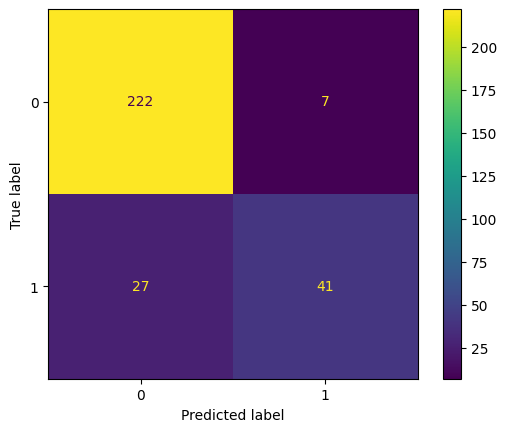

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
# cm = confusion_matrix(y_test_res, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

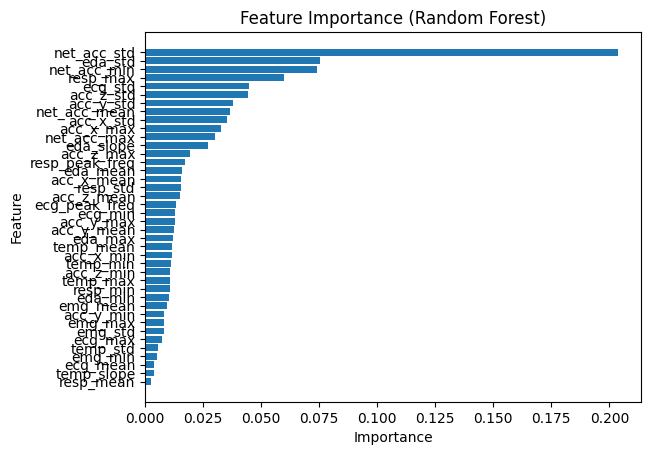

In [86]:
# import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
importances = model.feature_importances_
feature_names = x_test.columns  # or your dataset column names

df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort (important!)
df = df.sort_values(by="importance", ascending=False)

# Plot
plt.figure()
plt.barh(df["feature"], df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()  # highest on top
plt.show()

In [69]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=train.drop("label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [70]:
explanation = explainer.explain_instance(
    data_row=x_test.iloc[0].values,   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=100
)

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [71]:
y_test.iloc[0]

np.int64(0)

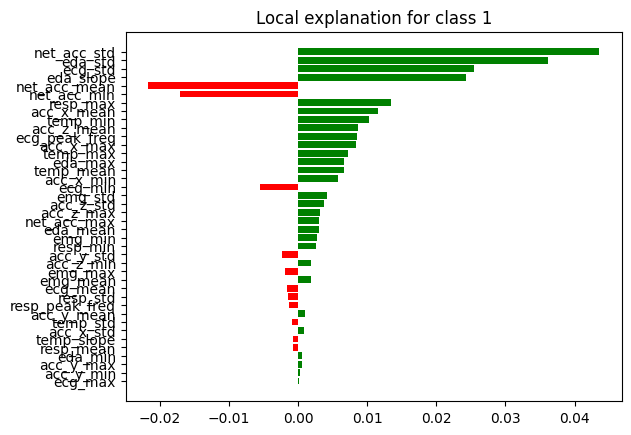

In [72]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

In [74]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(x_test)

In [78]:
x_test.shape

(297, 40)

In [77]:
shap_values.shape

(297, 40, 2)

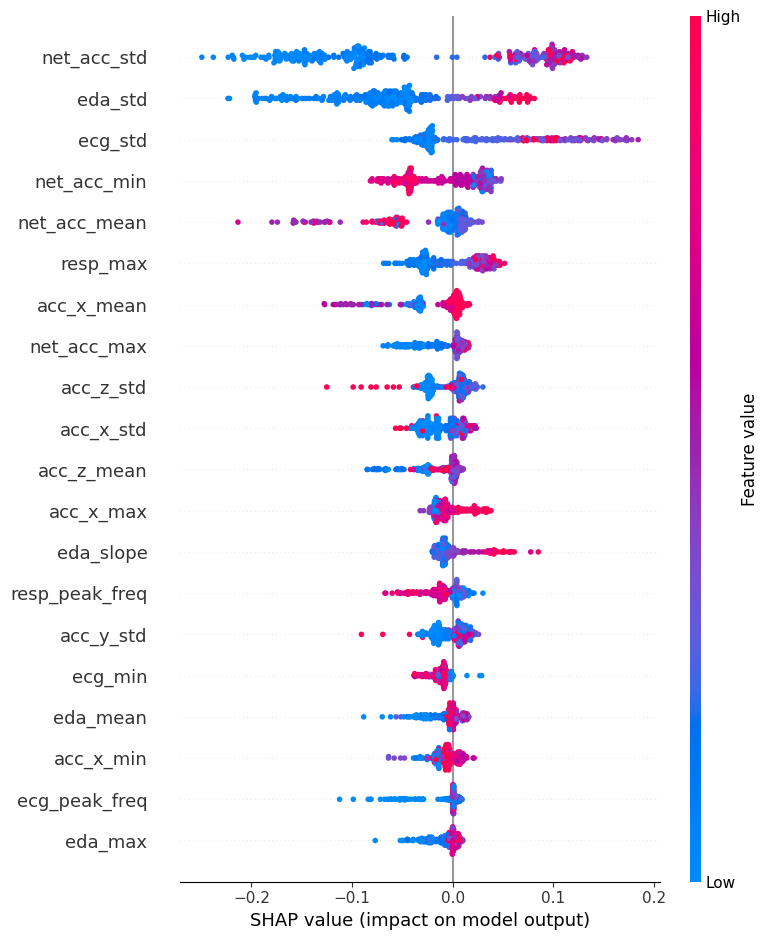

In [83]:
shap.summary_plot(shap_values[:, :, 1], x_test)

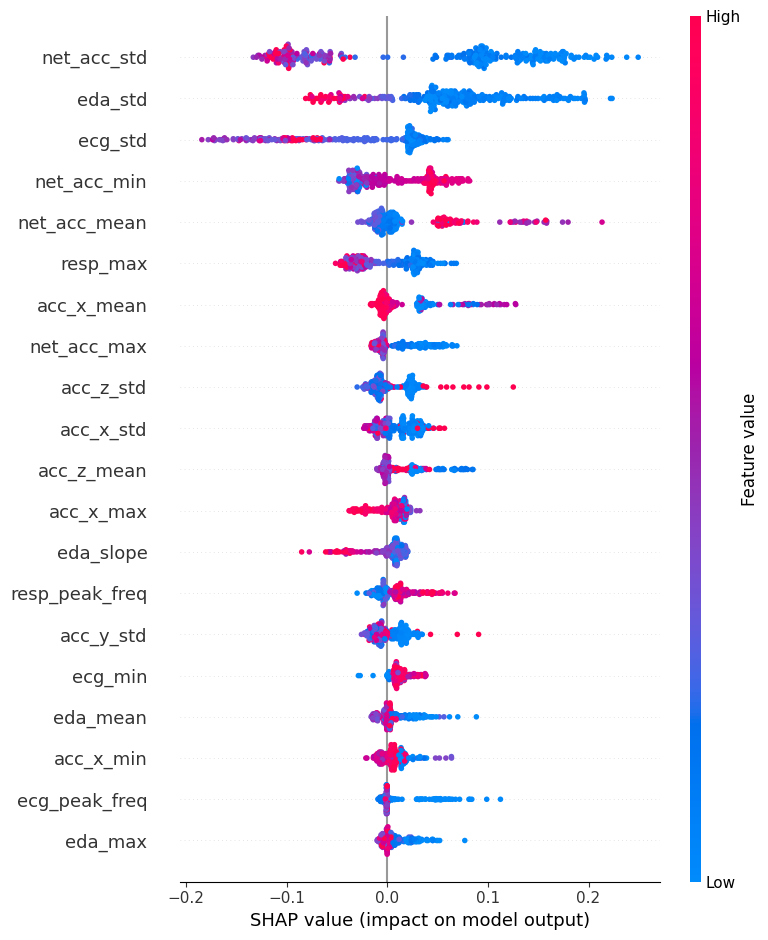

In [84]:
shap.summary_plot(shap_values[:, :, 0], x_test)